# Rapalog Discovery Pipeline
## 01 Exploratory Analysis notebook
### **Phase 1: Exploratory Data Analysis Workflow**
A. Load COCONUT Database (Full version)
B. Verify RDKit converts SMILES string into a molecule object
C. Quantify amount of missing SMILES data
D. Calculate molecular weight and show distribution from SMILES using RDKit
E. Rapamycin SMILES Data as sanity check

In [1]:
# Imports for notebook
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.data_processing as dp
import src.visualization as viz
importlib.reload(dp)
importlib.reload(viz)

from src.config import *
from src.data_processing import (
    load_coconut_database,
    verify_smiles_to_molecule,
    analyze_smiles_quality,
    calculate_molecular_weights,
    )
from src.visualization import plot_molecular_weight_distribution

In [2]:
# P0.A Load COCONUT Database (Full version)
# Loads databse, prints columns, and header
df = load_coconut_database(
    filename="coconut_csv-04-2026.csv",
    skip_loading=SKIP_COCONUT_LOADING
)

/Users/alangale/Projects/rapalog-discovery-pipeline/src/data_processing.py:48: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Loaded COCONUT data from: /Users/alangale/Projects/rapalog-discovery-pipeline/data/raw/coconut_csv-04-2026.csv
Index(['identifier', 'canonical_smiles', 'standard_inchi',
       'standard_inchi_key', 'name', 'iupac_name', 'annotation_level',
       'total_atom_count', 'heavy_atom_count', 'molecular_weight',
       'exact_molecular_weight', 'molecular_formula', 'alogp',
       'topological_polar_surface_area', 'rotatable_bond_count',
       'hydrogen_bond_acceptors', 'hydrogen_bond_donors',
       'hydrogen_bond_acceptors_lipinski', 'hydrogen_bond_donors_lipinski',
       'lipinski_rule_of_five_violations', 'aromatic_rings_count',
       'qed_drug_likeliness', 'formal_charge', 'fractioncsp3',
       'number_of_minimal_rings', 'van_der_walls_volume', 'contains_sugar',
       'contains_ring_sugars', 'contains_linear_sugars', 'murcko_framework',
       'np_likeness', 'chemical_class', 'chemical_sub_class',
       'chemical_super_class', 'direct_parent_classification',
       'np_classifier_

In [3]:
# P0.B Verify RDKit converts SMILES string into a molecule object (on subset of data)
valid_count = verify_smiles_to_molecule(
    df,
    smiles_column="canonical_smiles",
    sample_size=1000,
    skip_loading=SKIP_COCONUT_LOADING,
    )

Valid molecules: 1000/1000


In [4]:
# P0.C Quantify amount of missing/invalid SMILES across the full dataframe
smiles_quality = analyze_smiles_quality(
    df,
    smiles_column="canonical_smiles",
    skip_loading=SKIP_COCONUT_LOADING,
    )

[21:50:31] WARNING: not removing hydrogen atom without neighbors
[21:50:31] WARNING: not removing hydrogen atom without neighbors
[21:50:31] WARNING: not removing hydrogen atom without neighbors
[21:50:38] WARNING: not removing hydrogen atom without neighbors
[21:50:38] WARNING: not removing hydrogen atom without neighbors
[21:50:42] WARNING: not removing hydrogen atom without neighbors
[21:50:44] WARNING: not removing hydrogen atom without neighbors
[21:50:50] Explicit valence for atom # 1 P, 6, is greater than permitted
[21:50:52] Unusual charge on atom 37 number of radical electrons set to zero
[21:50:58] WARNING: not removing hydrogen atom without neighbors
[21:51:10] Unusual charge on atom 42 number of radical electrons set to zero
[21:51:12] WARNING: not removing hydrogen atom without neighbors
[21:51:12] WARNING: not removing hydrogen atom without neighbors
[21:51:15] Explicit valence for atom # 20 N, 5, is greater than permitted
[21:51:31] WARNING: not removing hydrogen atom wi

Total molecules: 738827
Missing SMILES: 0
Invalid SMILES: 4
Valid molecules: 738823
% Valid: 100.00%


Computing molecular weights...


[21:51:55] WARNING: not removing hydrogen atom without neighbors
[21:51:55] WARNING: not removing hydrogen atom without neighbors
[21:51:55] WARNING: not removing hydrogen atom without neighbors
[21:52:01] WARNING: not removing hydrogen atom without neighbors
[21:52:01] WARNING: not removing hydrogen atom without neighbors
[21:52:06] WARNING: not removing hydrogen atom without neighbors
[21:52:07] WARNING: not removing hydrogen atom without neighbors
[21:52:14] Explicit valence for atom # 1 P, 6, is greater than permitted
[21:52:15] Unusual charge on atom 37 number of radical electrons set to zero
[21:52:22] WARNING: not removing hydrogen atom without neighbors
[21:52:33] Unusual charge on atom 42 number of radical electrons set to zero
[21:52:36] WARNING: not removing hydrogen atom without neighbors
[21:52:36] WARNING: not removing hydrogen atom without neighbors
[21:52:39] Explicit valence for atom # 20 N, 5, is greater than permitted
[21:52:55] WARNING: not removing hydrogen atom wi

Invalid molecules (failed parsing): 4
Dataset size after cleaning: 738823

Molecular Weight Summary:
count    738823.000000
mean        509.475954
std         277.934687
min           1.008000
25%         334.456000
50%         432.528000
75%         608.735000
max        7860.709000
Name: MW, dtype: float64
Saved figure to: /Users/alangale/Projects/rapalog-discovery-pipeline/results/figures/molecular_weight_distribution.png


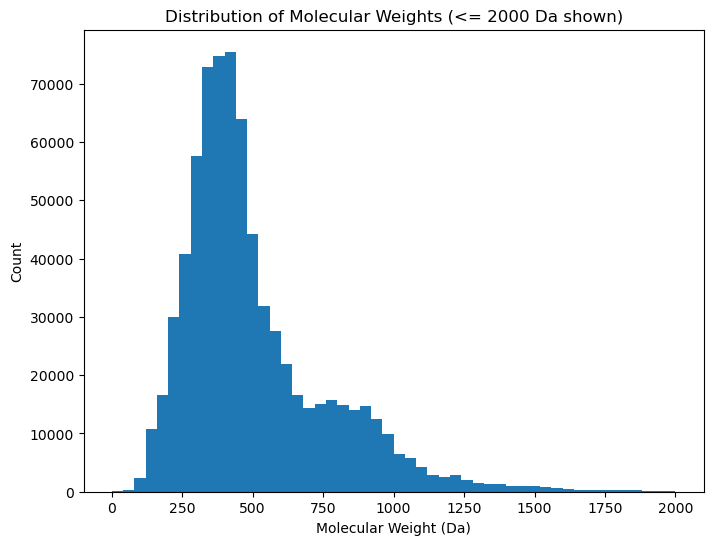

In [5]:
# P0.D Calculate molecular weight and show distribution from SMILES using RDKit
df = calculate_molecular_weights(
    df,
    smiles_column="canonical_smiles",
    mw_column="MW",
    skip_loading=SKIP_COCONUT_LOADING,
    )

if df is not None:
    print("\nMolecular Weight Summary:")
    print(df["MW"].describe())

    fig, ax = plot_molecular_weight_distribution(
        df,
        mw_column="MW",
        bins=50,
        plot_range=(0, 2000),
        save_path=str(PROJECT_ROOT / "results" / "figures" / "molecular_weight_distribution.png"),
    )
    plt.show()